## Paper Figure 5 - Functional clustering of neural responses

This script generates Figure 5 showing functional clustering of neural response types.
It includes UMAP visualization, cluster response profiles, coding score heatmaps,
population average responses, response metrics by cell type, and experience modulation analysis.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [ ]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Coding scores

In [ ]:

# # Define model version and load GLM results
# glm_version = '24_events_all_L2_optimize_by_session'

# run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
# run_params['figure_dir'] = os.path.join(save_dir, 'coding_scores_and_kernels')

# kernels = run_params['kernels']
# all_weights_df = pd.read_hdf( os.path.join(loading.get_glm_results_dir(), 'weights_df.h5'), key='df')

# all_results = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'all_results.h5'), key='df')

# all_results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'results_pivoted.h5'), key='df')
# all_results_pivoted = processing.set_negative_one_values_to_zero(all_results_pivoted)

# # Split out cell_specimen_id and ophys_experiment_id for results table
# all_results['cell_specimen_id'] = [
#     int(identifier.split('_')[1])
#     for identifier in all_results.identifier.values]

# all_results['ophys_experiment_id'] = [
#     int(identifier.split('_')[0])
#     for identifier in all_results.identifier.values]

# # Get results and weights just for platform paper experiments
# results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_pivoted.h5'), key='df')
# results_pivoted = processing.set_negative_one_values_to_zero(results_pivoted)

# # Make coding scores positive
# results_pivoted[processing.get_features_for_clustering()] = np.abs(
#     results_pivoted[processing.get_features_for_clustering()])

# weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_weights_df.h5'), key='df')



#### Clustering results

In [ ]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


#### Multi-Session Dataframes

In [ ]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# # Remove outliers
# threshold_percentile = 99.8  # for removing outliers for pl
# image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
# change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
# omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.pkl
there are 1881 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.pkl
there are 1879 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


## Plotting

### Clustered coding scores

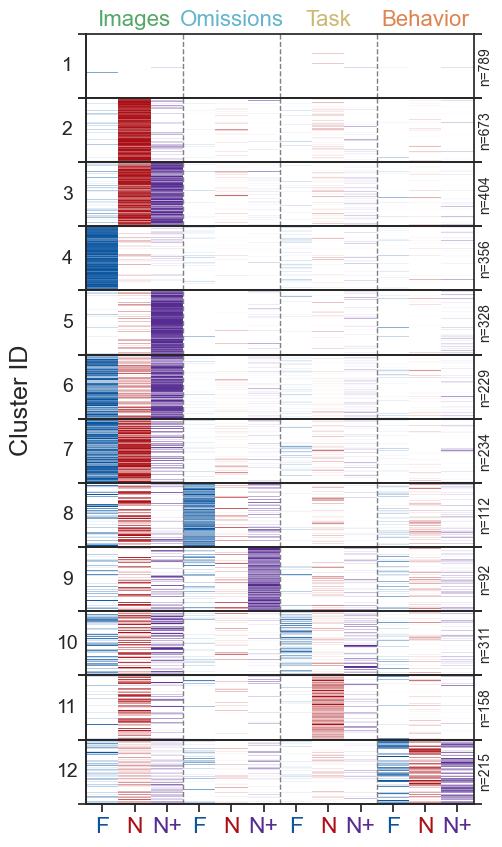

In [ ]:
plotting.plot_coding_score_heatmap_matched(cluster_meta, feature_matrix, sort_by='cluster_id',
                                        session_colors=True, experience_index=None, title='',
                                        save_dir=save_dir, folder='clustering_results', suffix='', ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1548: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cluster_means = feature_matrix.merge(cluster_meta[['cluster_id']], on='cell_specimen_id').groupby('cluster_id').mean()


<Axes: ylabel='Cluster ID'>

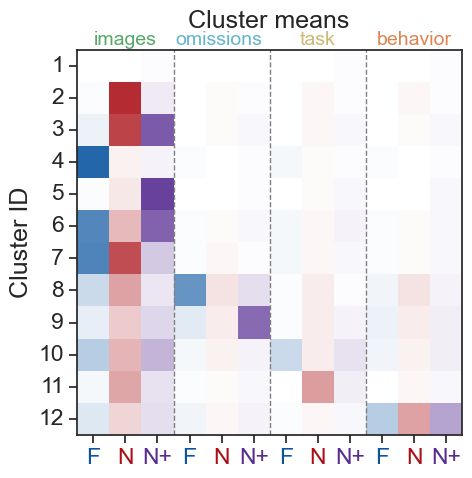

In [ ]:
plotting.plot_cluster_means_remapped(
    feature_matrix,
    cluster_meta,
    save_dir=save_dir,
    folder='figure_5_panels')


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1559: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cre_line_means = feature_matrix.merge(cluster_meta[['cre_line']], on='cell_specimen_id').groupby('cre_line').mean()


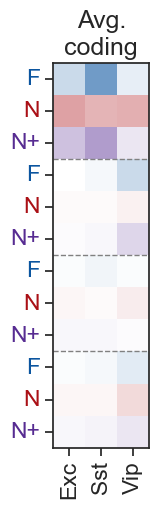

In [ ]:
 #plot average coding scores for each cre line (average of matched cells only)
plotting.plot_cre_line_means_remapped(feature_matrix, cluster_meta, save_dir=save_dir, folder='clustering_results')

### Average image, change, and omission responses per cluster

Generating Panel D: Population average responses...
Familiar
Novel
Novel +
Familiar
Novel
Novel +
Familiar
Novel
Novel +


array([<Axes: title={'center': 'Familiar'}>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

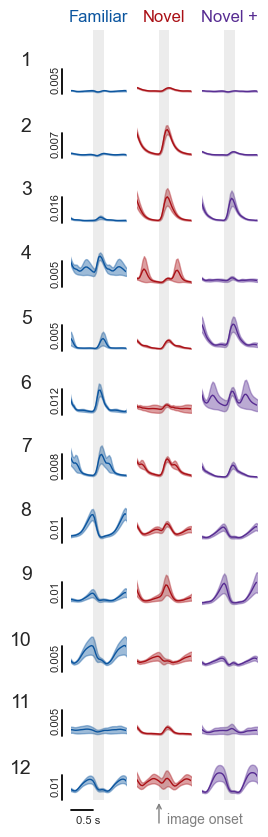

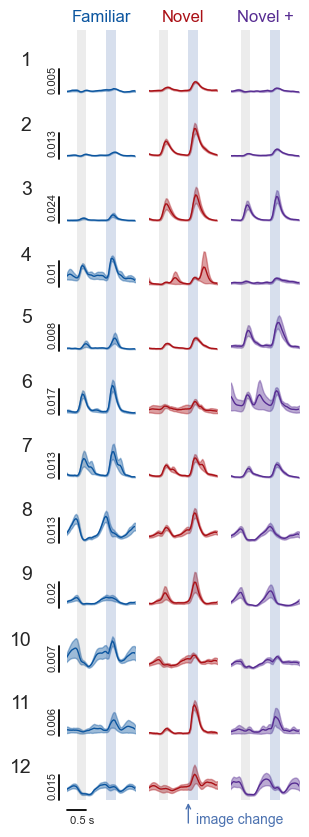

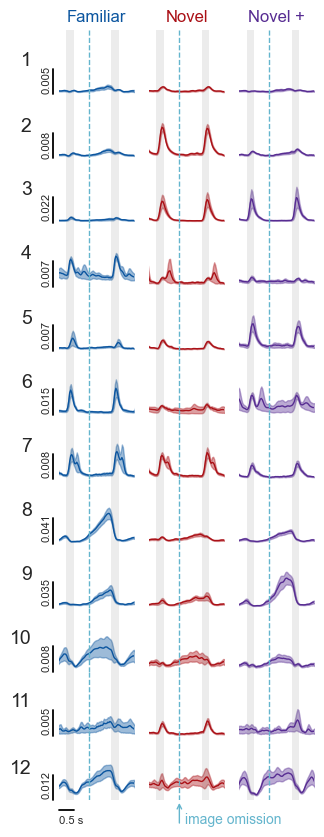

In [ ]:
print("Generating Panel D: Population average responses...")

# Image responses
event_type = 'images'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    image_mdf,
    event_type,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)

# Change responses
event_type = 'changes'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    change_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)

# Omission responses
event_type = 'omissions'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    omission_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)


12 3


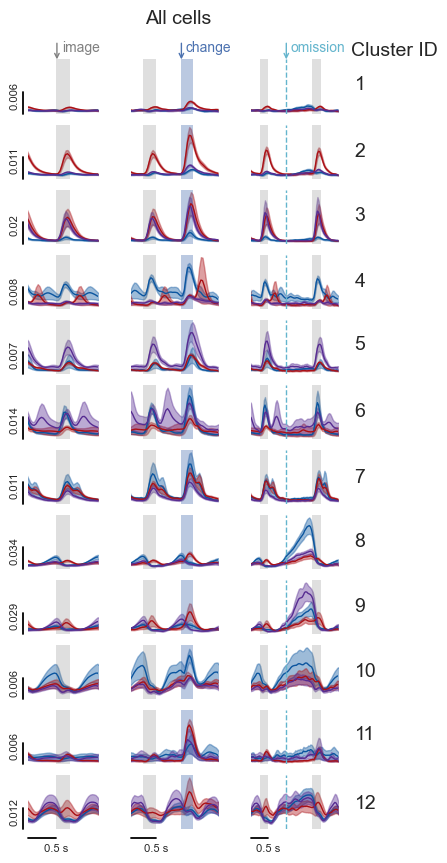

In [ ]:
# all cre lines together
suptitle = 'All cells'

plotting.plot_population_average_response_for_clusters_as_rows_all_response_types(image_mdf, change_mdf, omission_mdf, 
                                                                             save_dir=save_dir, suptitle=suptitle, cluster_order=None, ax=None);

24 total removed


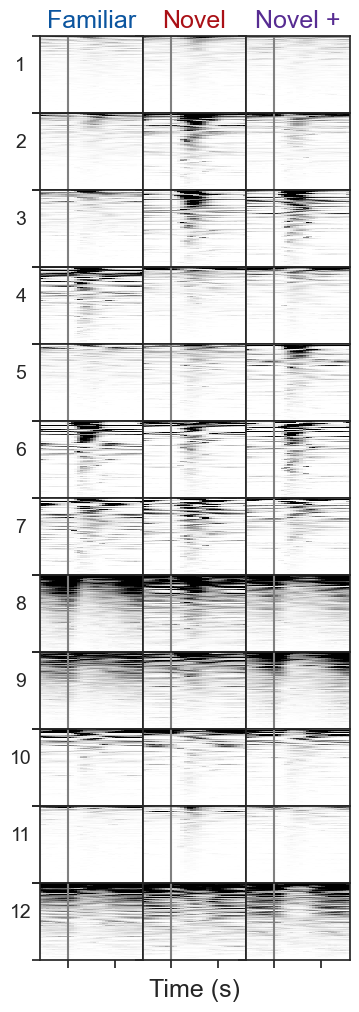

In [ ]:
# Response heatmaps for all cells 
plotting.plot_cell_response_heatmaps_for_clusters(image_mdf, data_type='events', event_type='images', 
                                                vmax=0.0005, xlim_seconds=[-0.3, 0.8], ax=None);

### Proportion cells per cluster per cell type 

In [ ]:
# save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_plots\figure_4\all_cre_clustering_113023'
metrics = processing.generate_merged_table_of_coding_score_and_model_free_metrics(cluster_meta, results_pivoted,
                                                                 data_type='events',
                                                                 session_subset='full_session',
                                                                 inclusion_criteria='platform_experiment_table',
                                                                 save_dir=loading.get_cell_metrics_dir())


# Replace dominant experience level cluster with correct one
cluster_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)

cluster_metrics = cluster_metrics.rename(columns={'dominant_experience_level':'dominant_experience_level_cluster', 
                                                  'dominant_feature': 'dominant_feature_cluster'})


metrics = metrics.rename(columns={'dominant_experience_level_cluster':'dominant_experience_level_old', 
                                                  'dominant_feature_cluster': 'dominant_feature_old'})

response_metrics = metrics.merge(cluster_metrics.reset_index()[['cluster_id', 'dominant_experience_level_cluster', 'dominant_feature_cluster']])


filepath: /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/cell_metrics/merged_model_free_metrics_table_events_platform_experiment_table.csv
loading model free metrics table
['Familiar' 'Novel' 'Novel +']


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/processing.py:2249: RuntimeWarning: invalid value encountered in double_scalars
  exp_mod_persistence = (row['Novel +']-row['Novel'])/(row['Novel +']+row['Novel'])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/processing.py:2227: RuntimeWarning: invalid value encountered in double_scalars
  feature_selectivity = (values[0] - (np.mean(values[1:]))) / (values[0] + (np.mean(values[1:])))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/processing.py:2231: RuntimeWarning: invalid value encountered in double_scalars
  experience_selectivity = (values[0] - (np.mean(values[1:]))) / (values[0] + (np.mean(values[1:])))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/processing.py:2243: RuntimeWarning: invalid value

3901 cells in coding score metrics table
coding score metrics table saved
Index(['index', 'cell_specimen_id', 'dominant_feature',
       'dominant_experience_level', 'next_highest_conditions',
       'max_coding_score', 'max_image_coding_score', 'image_coding_Familiar',
       'image_coding_Novel', 'image_coding_Novel +', 'feature_selectivity',
       'experience_selectivity', 'experience_modulation', 'exp_mod_direction',
       'exp_mod_persistence', 'feature_sel_within_session',
       'feature_sel_across_sessions', 'cluster_id', 'labels',
       'ophys_experiment_id', 'behavior_session_id', 'ophys_session_id',
       'ophys_container_id', 'mouse_id', 'indicator', 'full_genotype',
       'driver_line', 'cre_line', 'reporter_line', 'sex', 'age_in_days',
       'imaging_depth', 'targeted_structure', 'targeted_imaging_depth',
       'imaging_plane_group', 'project_code', 'session_type', 'session_number',
       'image_set', 'behavior_type', 'passive', 'experience_level',
       'prior_e

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2565: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2565: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2565: FutureWarning: 

Passing `palette` without assigning `hue` is dep

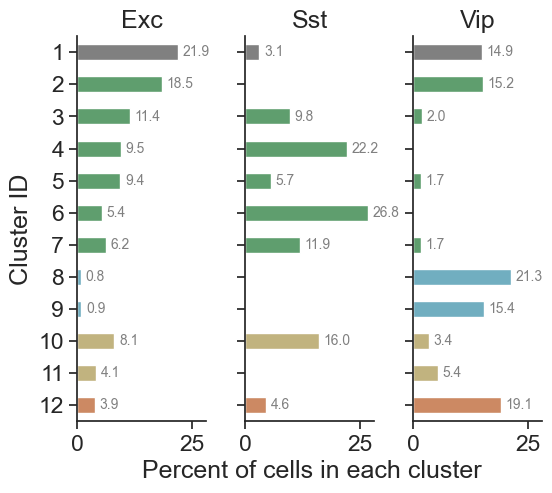

In [ ]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(tmp, cluster_order=None, 
                                                                 col_to_group='cre_line', save_dir=save_dir)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2638: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=all_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2664: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i+1] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2664: FutureWarning: 

Passing `palette` without assigning `hue` is d

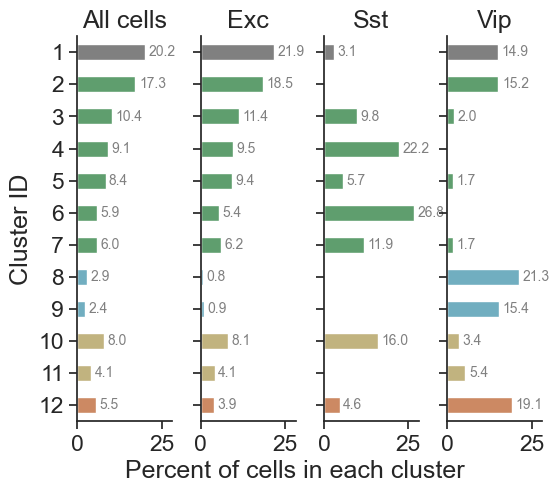

In [ ]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_and_all(tmp, col_to_group='cre_line', save_dir=save_dir)

array([<Axes: title={'center': 'Exc'}>, <Axes: title={'center': 'Sst'}>,
       <Axes: title={'center': 'Vip'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: ylabel='Percent of cells in each cluster'>, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Exc'>, <Axes: xlabel='Sst'>,
       <Axes: xlabel='Vip'>], dtype=object)

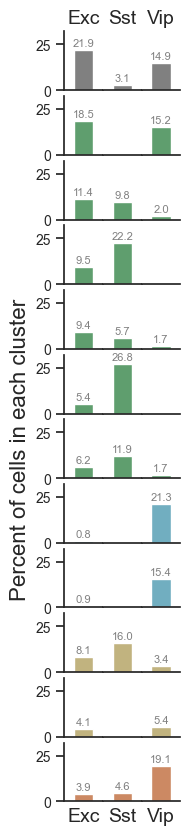

In [ ]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')


plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature_xaxis(tmp, col_to_group='cre_line', match_height=True,
                                                            cluster_order=None, save_dir=save_dir)

### Proportion of cells per cluster per depth 

In [ ]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each depth'

n_cells_table = processing.get_cluster_proportion_stats_for_locations(cluster_meta, location=location)
n_cells_table = n_cells_table.reset_index()

NameError: name 'processing' is not defined

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    data = n_cells_table[n_cells_table.cre_line==cre_line]
    pivot = data.pivot_table(index='cluster_id', columns='binned_depth', values='fraction_cells_location')
    # fill in blank values
    for cluster_id in np.arange(1, 13,1): 
        if cluster_id not in pivot.index.values: 
            pivot.loc[cluster_id] = np.nan
    # order
    pivot = pivot.loc[np.arange(1, 13,1)]
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], 
                        annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction cells per depth'})
    ax[i].set_yticklabels(pivot.index.values, rotation=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1) 
fig.subplots_adjust(wspace=0.4)

In [ ]:
def get_pivoted_data_for_cell_counts(n_cells_table, cre_line, cluster_ids=np.arange(1,13,1),
                                     column='binned_depth', value='fraction_cells_location'):
    data = n_cells_table[n_cells_table.cre_line==cre_line]
    pivot = data.pivot_table(index='cluster_id', columns=column, values=value)
    # fill in blank values
    for cluster_id in cluster_ids: 
        if cluster_id not in pivot.index.values: 
            pivot.loc[cluster_id] = np.nan
    # order numerically
    pivot = pivot.loc[cluster_ids]
    return pivot

get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_cells_location')

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',


array([<AxesSubplot:title={'center':'Exc'}, ylabel='Cluster ID'>,
       <AxesSubplot:title={'center':'Sst'}, xlabel='Fraction cells in each depth'>,
       <AxesSubplot:title={'center':'Vip'}>], dtype=object)

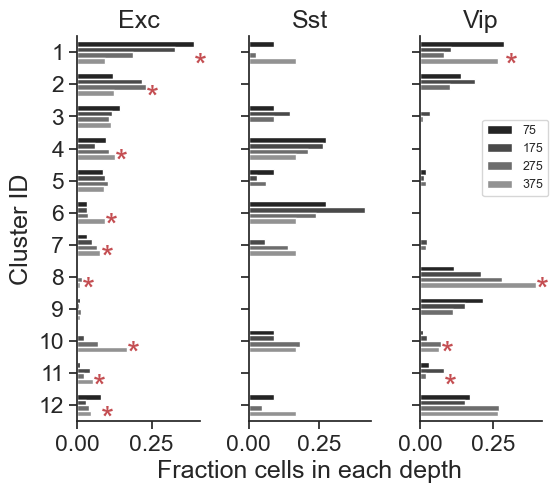

In [ ]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each depth'

plotting.plot_cluster_depth_distribution_by_cre_lines(cluster_meta, location, metric, horiz=False,
                                                      ylabel=ylabel, save_dir=save_dir, folder='cluster_properties')

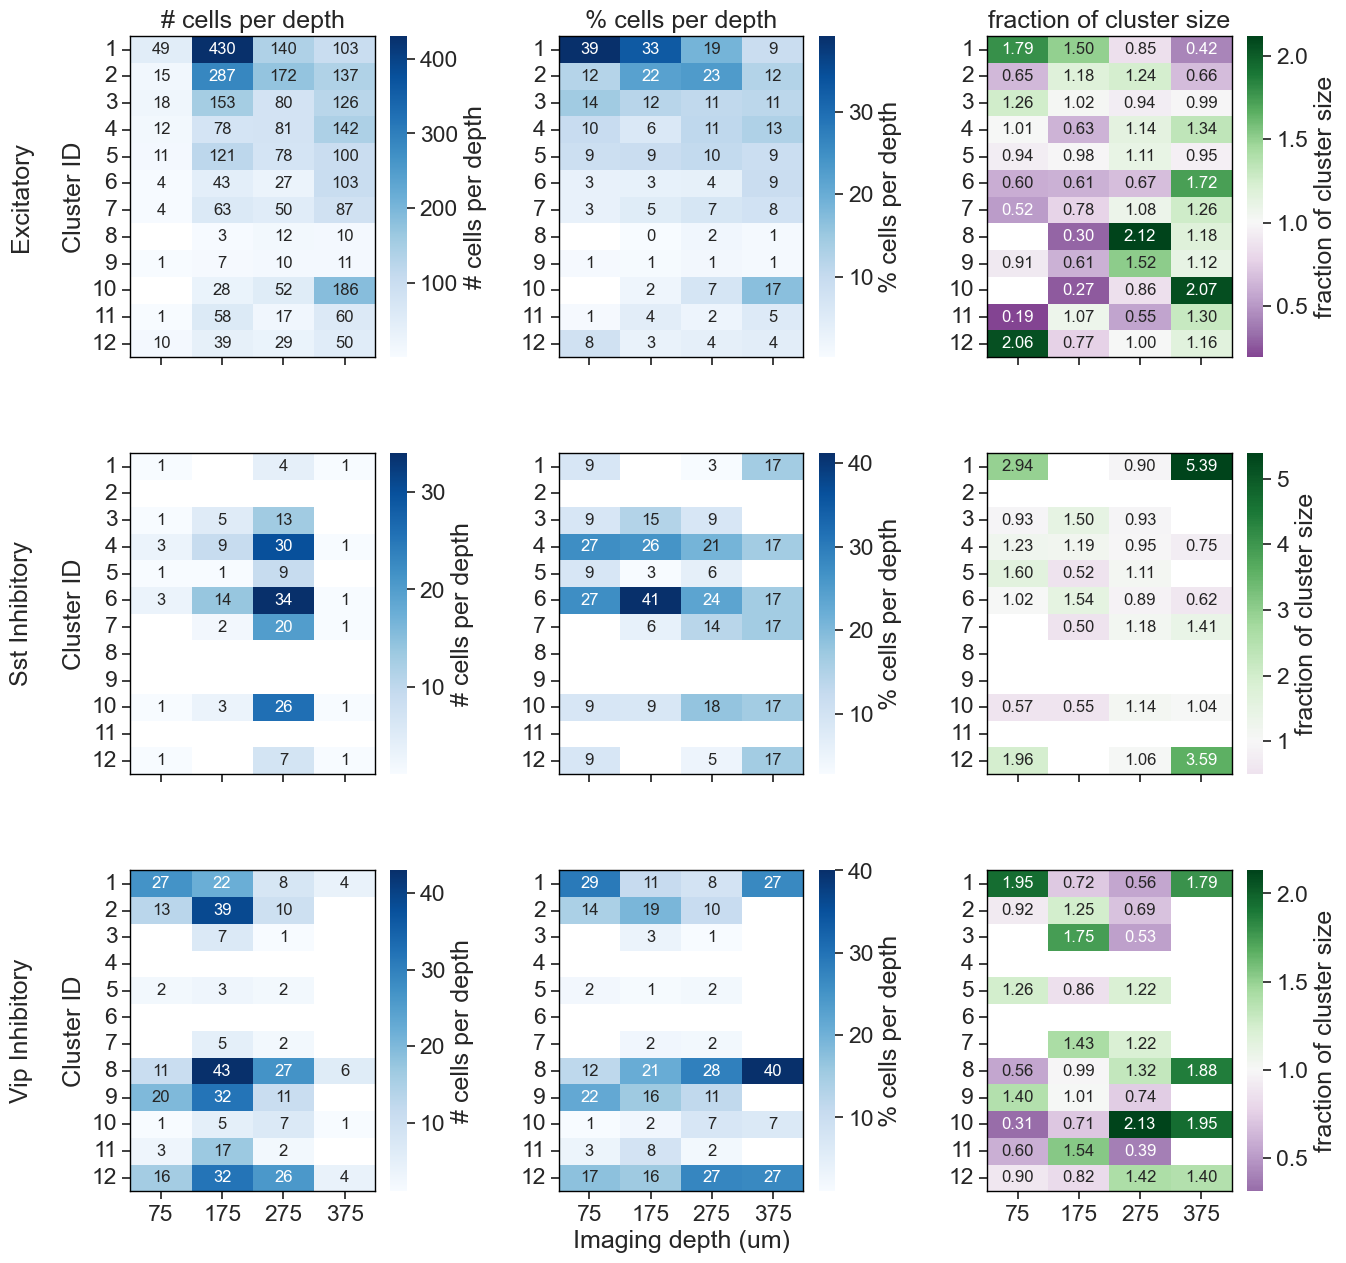

In [ ]:

cluster_ids = np.sort(n_cells_table.cluster_id.unique())

fig, ax = plt.subplots(3, 3, figsize=(15, 15), sharey=False, sharex=True)
ax = ax.ravel()
i=0
for c, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='n_cells_location', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'# cells per depth'})
    ax[i].set_ylabel(cell_type+'\n\nCluster ID')
    if c==0: 
        ax[i].set_title('# cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='percent_cells_location', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'% cells per depth'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('% cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_of_cluster_size', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='PRGn', center=1, ax=ax[i], annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction of cluster size'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('fraction of cluster size')
    i+=1

for i in range(9):
    ax[i].set_xlabel('') 
    ax[i].set_yticklabels(cluster_ids, rotation=0)
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)   
ax[7].set_xlabel('Imaging depth (um)')
fig.subplots_adjust(hspace=0.3, wspace=0.4)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5116: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  utils.save_figure(fig, figsize, save_dir, folder, 'cluster_proportions_cluster_types_legend')


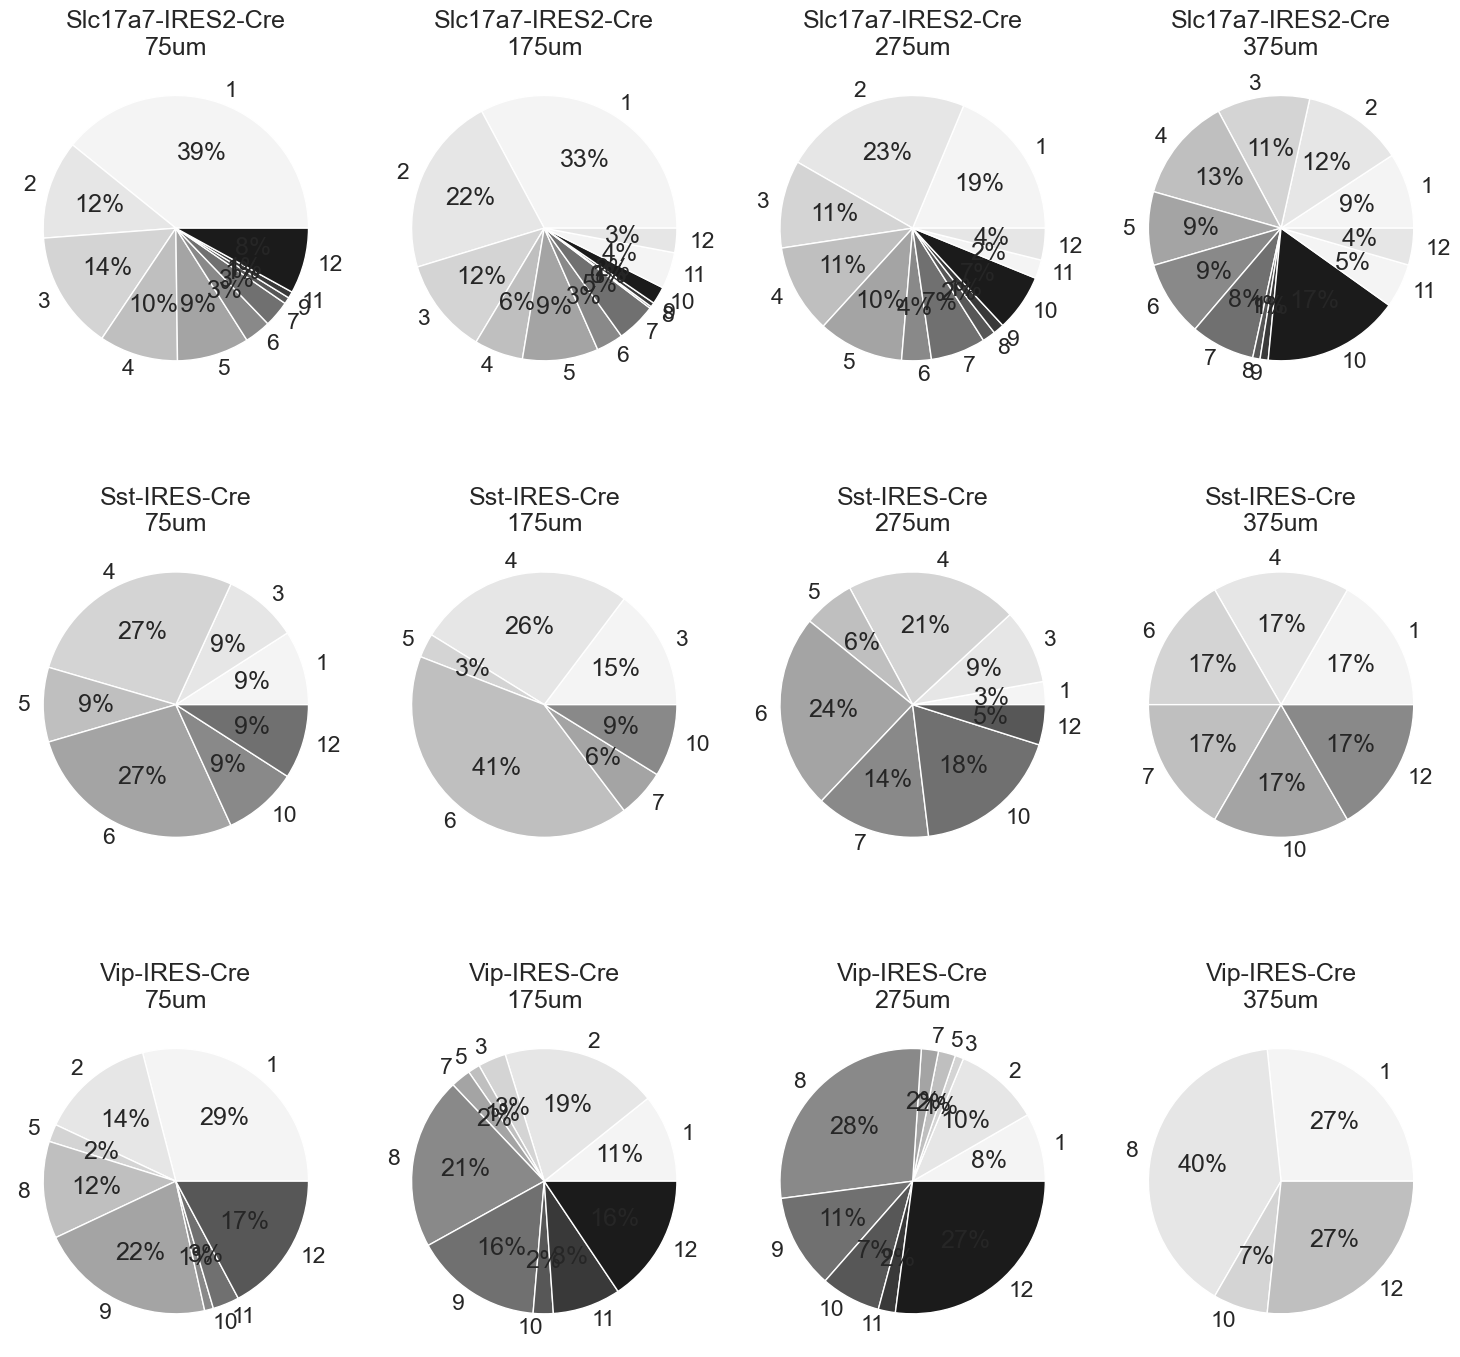

In [ ]:
plotting.plot_proportion_cells_per_depth_pie_chart(cluster_meta, save_dir=None, folder=None)

### Give clusters meaningful names and plot UMAP with names instead of cluster IDs

In [ ]:
import umap

In [ ]:
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [ ]:
# limit cluster meta to cells that are not in cluster 1 (which is an outlier in the plot)
main_cluster_meta = cluster_meta[cluster_meta.cluster_id!=1]
# limit umap_df to non-cluster 1
umap_df = umap_df.loc[main_cluster_meta.index.values]
# identify other non-outlier points and limit both tables to those
csids = umap_df[umap_df.x<16].index.values
main_cluster_meta = main_cluster_meta.loc[csids]
umap_df = umap_df.loc[csids]
print(len(umap_df), len(main_cluster_meta))
umap_df.head()

2941 2941


,x,y,cluster_id
cell_specimen_id,,,
1086489847,4.780380,7.625232,12
1086489860,9.371953,2.737884,2
1086489891,4.785028,7.619345,12
1086489976,6.144250,11.332527,4
1086490002,9.028252,10.901272,4


In [ ]:
exp_colors = utils.get_experience_level_colors()
gray = (0.8, 0.8, 0.8)
cluster_color_dict = {1: gray, # non coding - gray
                      2: exp_colors[1], # novel image coding - red
                      3: exp_colors[2], # persistent novel image coding - purple 
                      4: exp_colors[0], # familiar image coding - blue
                      5: gray, # weird coding - gray
                      6: exp_colors[2], # novelty suppression - purple
                      7: gray, # everything coding gray
                      8: exp_colors[0], # omission coding during familiar - blue
                      9: exp_colors[2], # omission coding during novel+ - purple
                      10: exp_colors[0], # task coding during familiar - blue
                      11: gray, # task coding during novel - gray
                      12: gray, # behavior coding - gray
                      }

colors = [cluster_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

feature_colors = plotting.get_feature_colors_with_gray()
edge_color_dict = {1: gray, # non coding - gray
                      2: feature_colors[1], # image coding
                      3: feature_colors[1], # image coding
                      4: feature_colors[1], # image coding
                      5: gray, # image coding
                      6: feature_colors[1], # image coding 
                      7: gray, # image coding
                      8: feature_colors[2], # omission coding
                      9: feature_colors[2], # omission coding
                      10: feature_colors[3], # task coding
                      11: gray, # task coding
                      12: feature_colors[4], # behavior coding
                      }

edge_colors = [edge_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: '', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red
                3: 'novel image coding', # persistent novel image coding - purple 
                4: 'familiar image coding', # familiar image coding - blue
                5: '', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - purple
                7: '', # everything coding gray
                8: 'omission coding', # omission coding during familiar - blue
                9: 'omission coding', # omission coding during novel+ - purple
                10: 'task coding', # task coding during familiar - blue
                11: '', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - gray
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


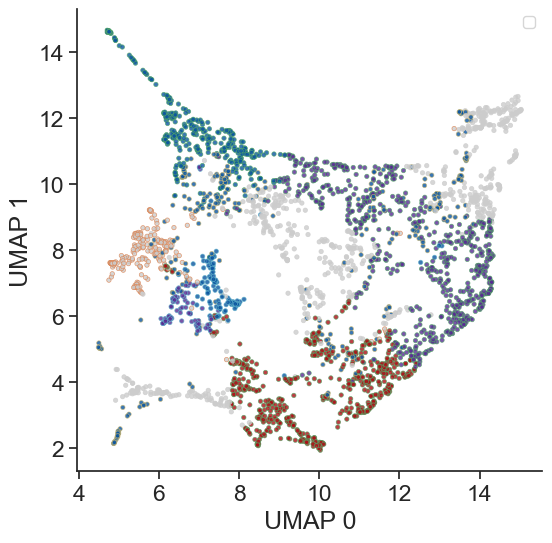

In [ ]:
figsize = (6, 6)

fig, ax = plt.subplots(figsize=figsize)

umap_df['labels'] = labels
ax = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax, #label=labels,
                     color=colors, edgecolor=edge_colors, markers=markers, linewidth=0.5, alpha=0.8)

ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


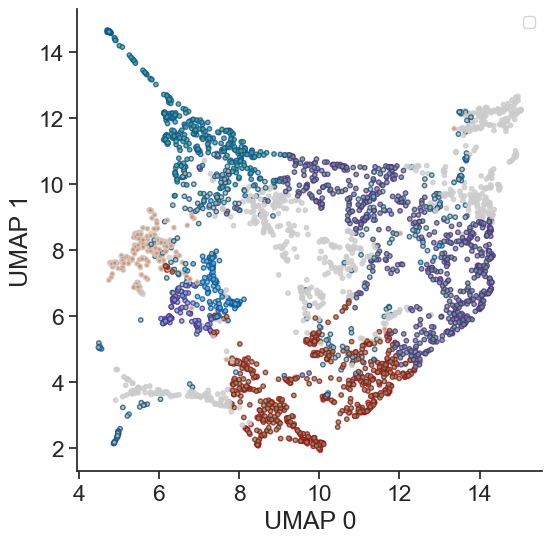

In [ ]:
figsize = (6, 6)

fig, ax = plt.subplots(figsize=figsize)

umap_df['labels'] = labels
ax = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax, #label=labels,
                     color=edge_colors, edgecolor=colors, markers=markers, linewidth=1, alpha=0.8)

ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))
# ax.set_title(utils.get_cell_type_for_cre_line(cre_line, cluster_meta))

# plt.subplots_adjust(wspace=0.3)
# if save_dir:
#     utils.save_figure(fig, figsize, save_dir, folder, 'UMAP_' + label_col)


Text(0, 0.5, 'UMAP 1')

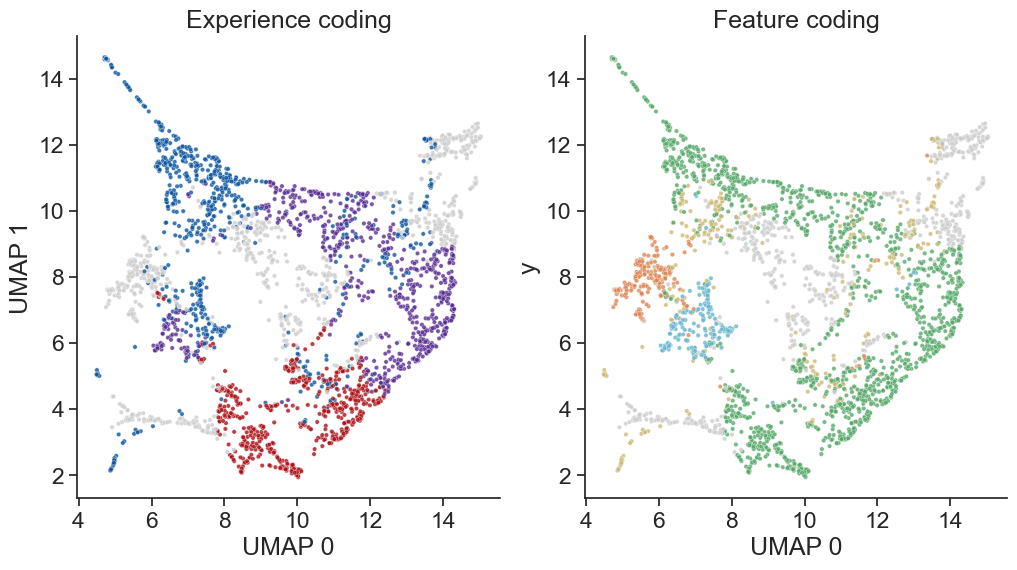

In [ ]:
figsize = (12, 6)

fig, ax = plt.subplots(1, 2, figsize=figsize)

umap_df['labels'] = labels
ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=edge_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')

In [ ]:
# umap_df['cell_type'] = [cell_type[:3] for cell_type in main_cluster_meta.cell_type.values]
# markers_dict = {'Exc': 'o', # '^'
#                 'Sst': 's', # 'o'
#                 'Vip': 'd'}

# figsize = (12, 6)

# fig, ax = plt.subplots(1, 2, figsize=figsize)

# umap_df['labels'] = labels
# ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], style='cell_type',
#                      color=colors, markers=markers_dict, alpha=0.8, linewidth=0)
# ax[0].set_title('Experience coding')
# ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], style='cell_type',
#                      color=edge_colors, markers=markers_dict, alpha=0.8, linewidth=0)
# ax[1].set_title('Feature coding')
# ax[0].set_xlabel('UMAP 0')
# ax[1].set_xlabel('UMAP 0')
# ax[0].set_ylabel('UMAP 1')

#### Try with new colors for specific cluster types

In [ ]:

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

cluster_id_labels = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


# gray = #BFBFBF
clutster_colors_dict = {1: '#BFBFBF', # non coding - gray #BFBFBF
                2: '#AB0F15', # novel image coding - red #AB0F15
                3: '#A2258F', # persistent novel image coding -  reddish purple #A2258F
                4: '#0B549D', # familiar image coding - blue #0B549D
                5: '#BFBFBF', # weird coding - gray
                6: '#E38686', # novelty suppression - light red #E38686
                7: '#BFBFBF', # everything coding gray
                8: '#71A9DE', # omission coding during familiar - light blue #71A9DE
                9: '#9A79C9', # omission coding during novel+ - light purple #9A79C9
                10: '#DBD689', # task coding during familiar - yellow #DBD689
                11: '#BFBFBF', # task coding during novel - gray
                12: '#FAB171', # behavior coding - orange #FAB171
                }
new_colors = [clutster_colors_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

In [ ]:
umap_df['cluster_id'] = [main_cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in main_cluster_meta.cell_type.values]
umap_df.head()

,x,y,cluster_id,labels,cluster_label,cell_type
cell_specimen_id,,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,familiar image coding,Sst Inhibitory


In [ ]:
red = sns.color_palette('Reds_r', 6).as_hex()[0]
blue = sns.color_palette('Blues_r', 6).as_hex()[0]
purple = sns.color_palette('Purples_r', 6).as_hex()[0]
print(red, blue, purple)

red = sns.color_palette('Reds_r', 6).as_hex()[2]
blue = sns.color_palette('Blues_r', 6).as_hex()[2]
purple = sns.color_palette('Purples_r', 6).as_hex()[2]
print(red, blue, purple)

#aa1016 #0b559f #572c92
#f44f39 #539ecd #8d89c0


In [ ]:
hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF


Text(0.5, 1.0, 'Main clusters')

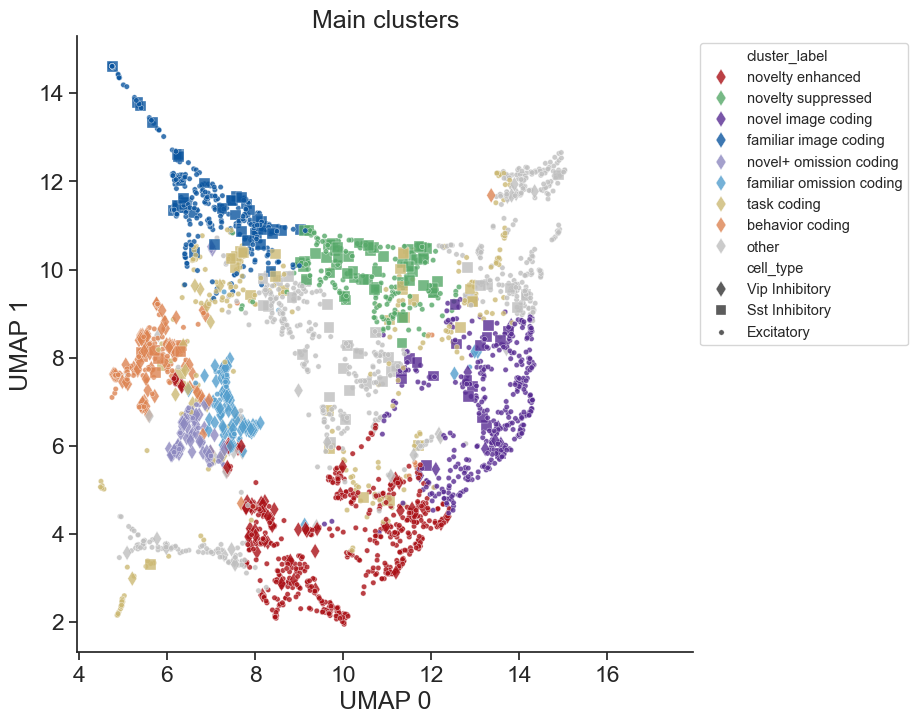

In [ ]:
figsize = (8,8)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_label', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Main clusters')

In [ ]:
gray_cluster_ids = ['cluster 1', 'cluster 5', 'cluster 7', 'cluster 11']
umap_df['cluster_id'] = ['other' if cluster_id in gray_cluster_ids else cluster_id for cluster_id in umap_df.cluster_id.values]
umap_df.cluster_id.unique()

array(['cluster 12', 'cluster 2', 'cluster 4', 'cluster 3', 'cluster 10',
       'other', 'cluster 6', 'cluster 8', 'cluster 9'], dtype=object)

In [ ]:
cluster_ids = np.sort(umap_df.cluster_id.unique())
gray_cluster_ids = [cluster_id for cluster_id in cluster_ids if cluster_id!='cluster 10']

umap_df['cluster_id'] = ['other' if cluster_id in gray_cluster_ids else cluster_id for cluster_id in umap_df.cluster_id.values]
umap_df.cluster_id.unique()

hue_order = ['cluster 10',  'other']
palette = ['#000000', '#BFBFBF']

Text(0.5, 1.0, 'Cluster 10')

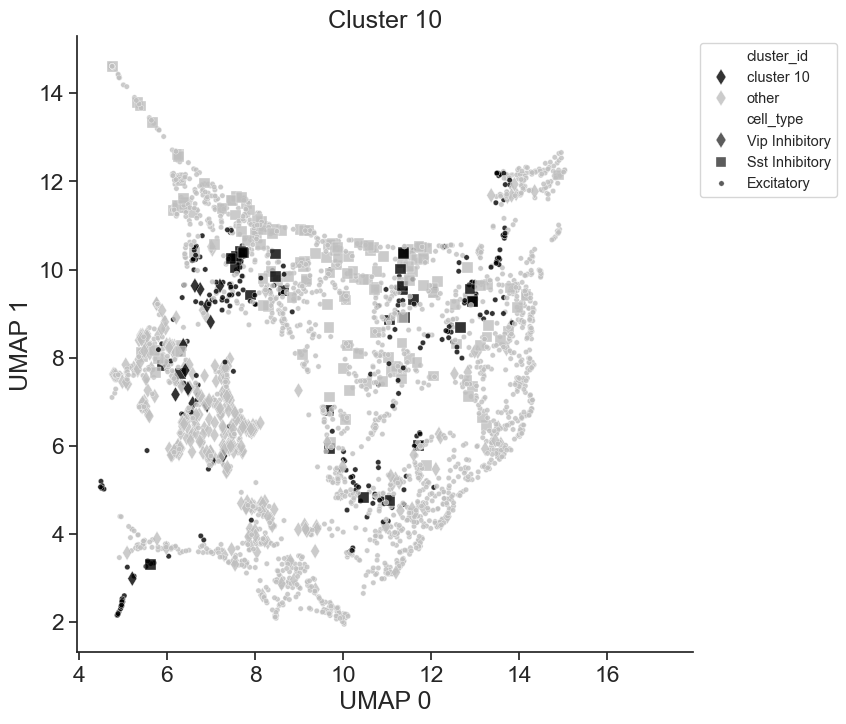

In [ ]:
figsize = (8,8)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_id', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Cluster 10')

#### pie charts

In [ ]:
hue_order = ['cluster 2', 'cluster 6', 'cluster 3', 'cluster 4',
             'cluster 9', 'cluster 8', 'cluster 10', 'cluster 12', 
             'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF


In [ ]:
labels_dict = {1: 'non-coding', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'novel image coding', # weird coding -reddish purple
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'unselective', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'task coding', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


In [ ]:
hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF', # unselective
            '#BFBFBF',] # non-coding - gray #BFBFBF


In [ ]:
# get saved umap results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')

umap_df['cluster_id'] = [cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in cluster_meta.cell_type.values]
umap_df.head()

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


,x,y,cluster_id,cluster_label,cell_type
cell_specimen_id,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,Sst Inhibitory


In [ ]:
cluster_counts = umap_df.groupby(['cell_type', 'cluster_label']).count().rename(columns={'cluster_id':'n_cluster'})[['n_cluster']].reset_index()
cre_counts = umap_df.groupby(['cell_type']).count().rename(columns={'cluster_id':'n_cre'})[['n_cre']].reset_index()
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster']/counts['n_cre']
counts

,cell_type,cluster_label,n_cluster,n_cre,fraction
0,Excitatory,behavior coding,128,3298,0.038811
1,Excitatory,familiar image coding,313,3298,0.094906
2,Excitatory,familiar omission coding,25,3298,0.007580
3,Excitatory,non-coding,722,3298,0.218921
4,Excitatory,novel image coding,687,3298,0.208308
5,Excitatory,novel+ omission coding,29,3298,0.008793
6,Excitatory,novelty enhanced,611,3298,0.185264
7,Excitatory,novelty suppressed,177,3298,0.053669
8,Excitatory,task coding,402,3298,0.121892
9,Excitatory,unselective,204,3298,0.061856


In [ ]:
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

In [ ]:
cell_type = 'Vip Inhibitory'

data = counts[counts.cell_type==cell_type]

fractions = []
colors = []
cluster_labels = []
for i, cluster_label in enumerate(hue_order): 
    tmp = data[data.cluster_label==cluster_label]
    if len(tmp)>0: 
        fractions.append(tmp.fraction.values[0])
        colors.append(palette[i])
        cluster_labels.append(cluster_label.replace(' ','\n'))


In [ ]:
cluster_labels[3].replace(' ','\n')

'familiar\nomission\ncoding'

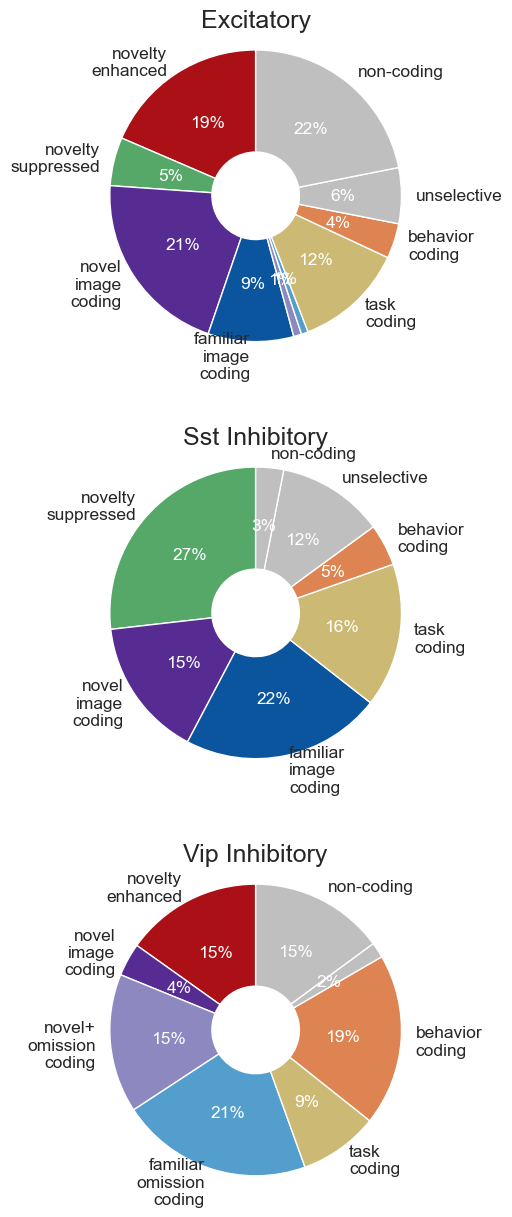

In [ ]:
figsize = (5, 15)
fig, ax = plt.subplots(3, 1, figsize=figsize)

for i, cell_type in enumerate(cell_types): 
    # get data for this cell type, with cluster labels & colors in a specific order
    data = counts[counts.cell_type==cell_type]
    fractions = []
    colors = []
    cluster_labels = []
    for c, cluster_label in enumerate(hue_order): 
        tmp = data[data.cluster_label==cluster_label]
        if len(tmp)>0: 
            fractions.append(tmp.fraction.values[0])
            colors.append(palette[c])
            if tmp.fraction.values[0]<=0.03: 
                label = ''
            else: 
                label = cluster_label.replace(' ','\n')
            cluster_labels.append(label)

    # plot it 
    wedges, texts, autotexts = ax[i].pie(fractions, 
                                        labels=cluster_labels, 
                                        autopct='%.0f%%',
                                        startangle=90, 
                                        wedgeprops={'width': 0.7, 'edgecolor': 'white'},   
                                        textprops={'size': 'x-small'},
                                        colors=colors) # Use a Seaborn color palette
    ax[i].axis('equal') 
    ax[i].set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

    # Equal aspect ratio ensures that pie is drawn as a circle.
plt.subplots_adjust(hspace=0.3)

### Proportion cells per area and depth for meaningfully named clusters

In [ ]:
clusters_to_keep = [2, 6, 3, 4, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel suppressed',
                 'novel images', 'familiar images',  
                 'familiar omissions', 'novel+ omissions', 
                 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]


fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=False)
ax = ax.ravel()
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'percent cells per depth'})
    pivot_sig = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='bh_significant', cluster_ids=clusters_to_keep)
    rows, cols = np.where(pivot_sig==1)
    coords = list(zip(rows, cols))
    for coord in coords: 
        ax[i].text(s='*',y=coord[0]+0.7, x=coord[1]+0.5, ha='center', va='top', color='r')
    ax[i].set_ylabel('')
    if i == 0:
        ax[i].set_yticklabels(cluster_names, rotation=0)
    else: 
        ax[i].set_yticklabels(clusters_to_keep, rotation=0)
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
# ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)  
fig.subplots_adjust(wspace=0.4)

In [ ]:
clusters_to_keep = [2, 6, 3, 4, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel suppressed',
                 'novel images', 'familiar images',  
                 'familiar omissions', 'novel+ omissions', 
                 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]


fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=False)
ax = ax.ravel()
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'percent cells per depth'})
    pivot_sig = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='bh_significant', cluster_ids=clusters_to_keep)
    rows, cols = np.where(pivot_sig==1)
    coords = list(zip(rows, cols))
    for coord in coords: 
        ax[i].text(s='*',y=coord[0]+0.7, x=coord[1]+0.5, ha='center', va='top', color='r')
    ax[i].set_ylabel('')
    if i == 0:
        ax[i].set_yticklabels(cluster_names, rotation=0)
    else: 
        ax[i].set_yticklabels(clusters_to_keep, rotation=0)
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
# ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)  
fig.subplots_adjust(wspace=0.4)

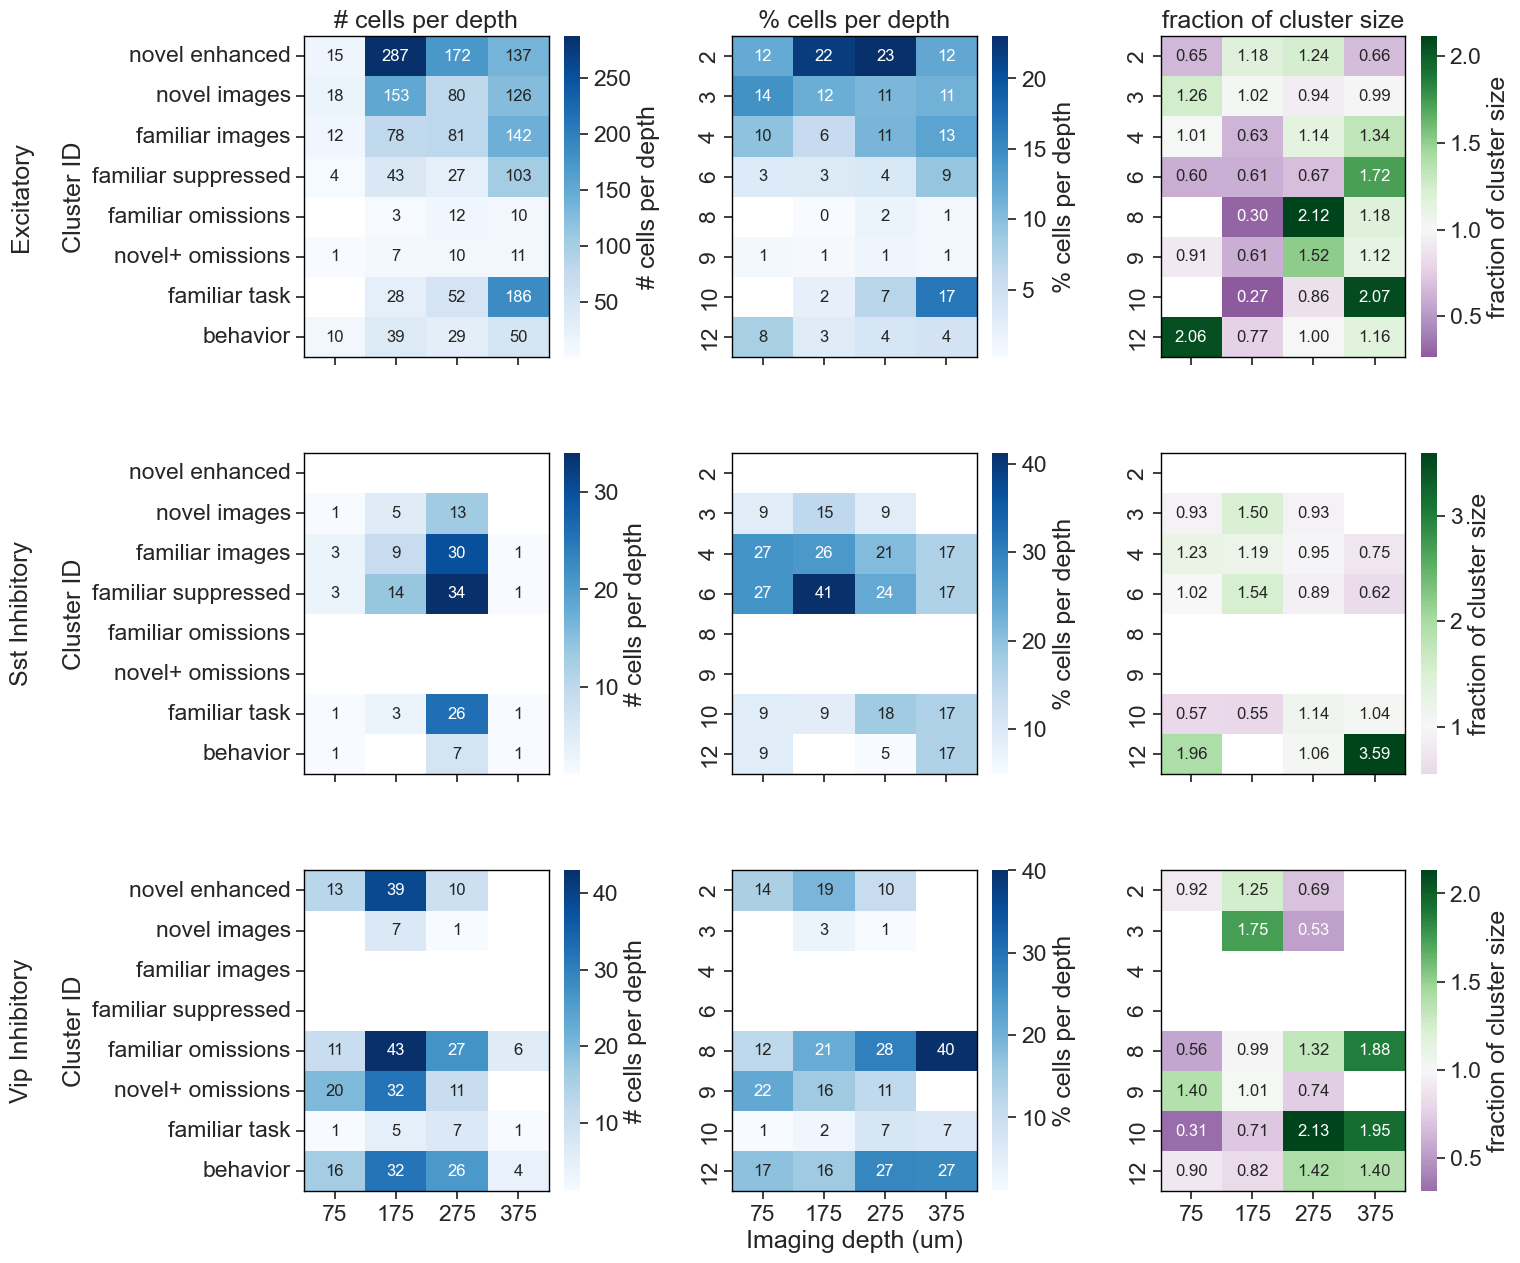

In [ ]:
clusters_to_keep = [2, 3, 4, 6, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel images', 'familiar images', 'familiar suppressed', 
                 'familiar omissions', 'novel+ omissions', 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]

fig, ax = plt.subplots(3, 3, figsize=(15, 15), sharey=False, sharex=True)
ax = ax.ravel()
i=0
for c, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='n_cells_location', cluster_ids=clusters_to_keep)
    pivot.index = cluster_names
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'# cells per depth'})
    ax[i].set_ylabel(cell_type+'\n\nCluster ID')
    ax[i].set_yticklabels(cluster_names, rotation=0)
    if c==0: 
        ax[i].set_title('# cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'% cells per depth'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('% cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_of_cluster_size', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='PRGn', center=1, ax=ax[i], annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction of cluster size'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('fraction of cluster size')
    i+=1

for i in range(9):
    ax[i].set_xlabel('') 
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)   
ax[7].set_xlabel('Imaging depth (um)')
fig.subplots_adjust(hspace=0.3, wspace=0.4)

### Single cell examples

cell_specimen_id: 1086514606
experience_level: Familiar
ophys_experiment_id: 989213060


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 991852002


...

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 991852002


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086514606
saved


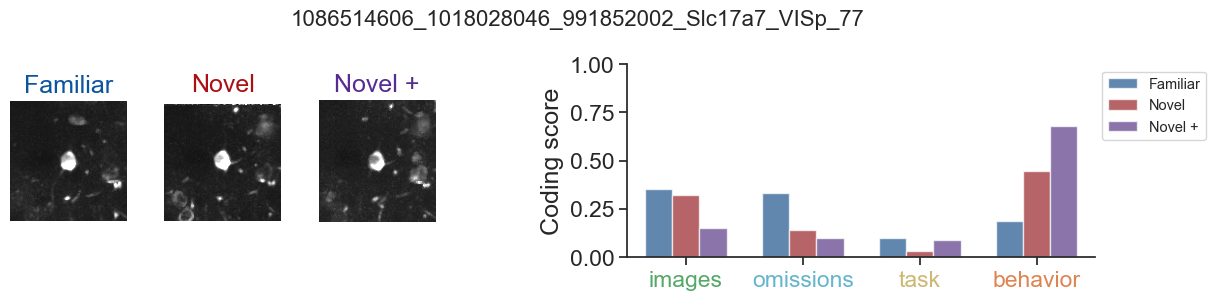

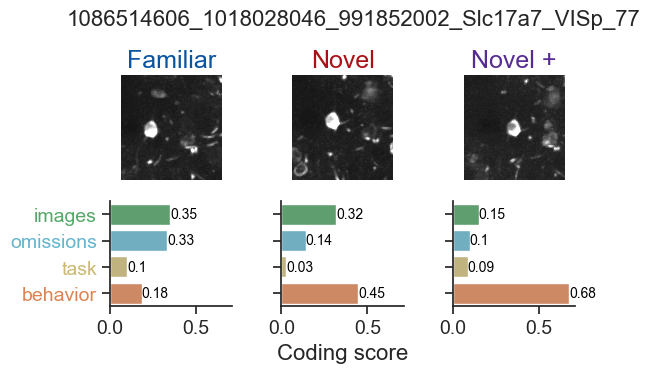

In [ ]:
# cell_specimen_id = 1086515505
cell_specimen_id = 1086514606 #Excitatory behavior coding cell

cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# # Plot cell change and omission responses
# pse.plot_cell_change_and_omission_responses(
#     change_mdf_example,
#     omission_mdf_example,
#     cell_specimen_id,
#     save_dir=save_dir)

Generating Panel G: Single cell examples...
cell_specimen_id: 1086620671
experience_level: Familiar
ophys_experiment_id: 956941846


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 960410028


...

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 960410028


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086620671
saved


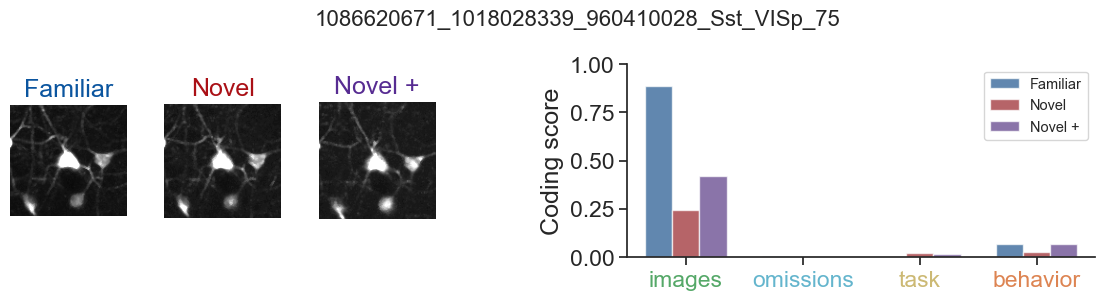

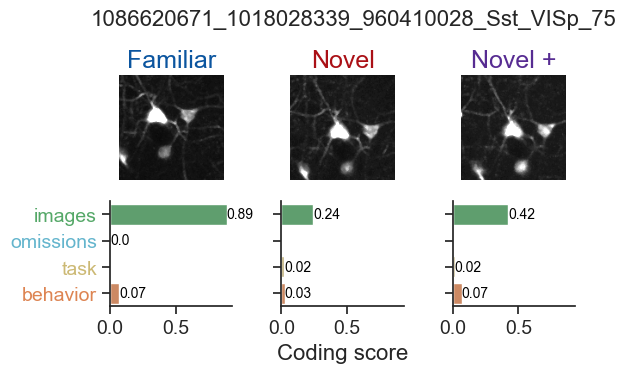

In [ ]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086620671  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# Plot cell change and omission responses
pse.plot_cell_change_and_omission_responses(
    change_mdf_example,
    omission_mdf_example,
    cell_specimen_id,
    save_dir=save_dir)


cell_specimen_id: 1086628708
experience_level: Familiar
ophys_experiment_id: 882551935


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 885146239


...

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 885146239


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086628708
saved


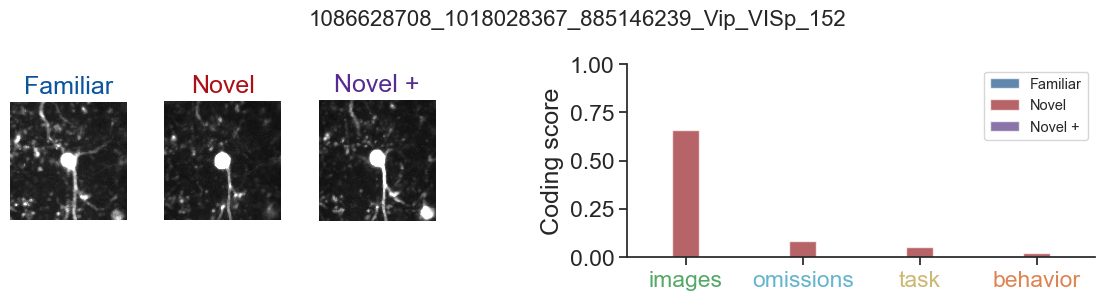

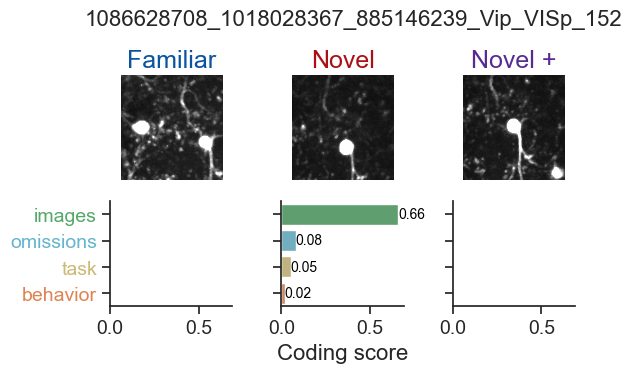

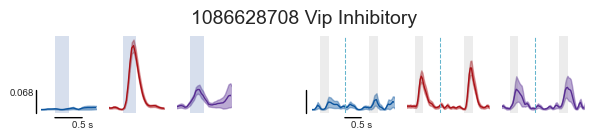

In [ ]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086628708  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# Plot cell change and omission responses
pse.plot_cell_change_and_omission_responses(
    change_mdf_example,
    omission_mdf_example,
    cell_specimen_id,
    save_dir=save_dir)
